# Поліноміальна регресія та регуляризація
Поліноми - вирази, до яких входять цілі ступені змінної:
$\sum_{i=0}^{N}a_i\cdot x^i$

Ступенем полінома називають його максимальний ступінь $N$, при $N=1$ маємо лінію (лінійну регресію).
При більших ступенях мова іде про нелінійну регресію.

## Завдання 1
Перевірте, як поліноміальні ознаки впливають на якість моделі:

- Згенеруйте синтетичні дані за допомогою make_regression (n_samples=200, n_features=1, noise=15, random_state=42).
- Побудуйте модель лінійної регресії на вихідних даних.
- Додайте поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
- Навчіть модель на розширеному наборі ознак.
- Побудуйте графік: вихідні точки та лінії передбачень для обох моделей.

In [1]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

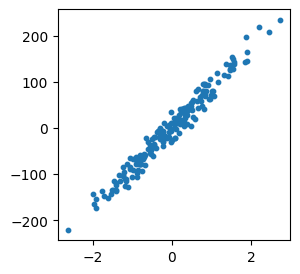

In [2]:
# Згенеруйте синтетичні дані за допомогою make_regression (n_samples=200, n_features=1, noise=15, random_state=42).
X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
_, ax = plt.subplots(figsize=(3,3))
ax.scatter(X, y, s=10)
plt.show()

In [3]:
# Побудуйте модель лінійної регресії на вихідних даних.
model1 = LinearRegression()
model1.fit(X, y)

# Додайте поліноміальні ознаки ступеня 2 за допомогою PolynomialFeatures.
model2 = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
model2.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


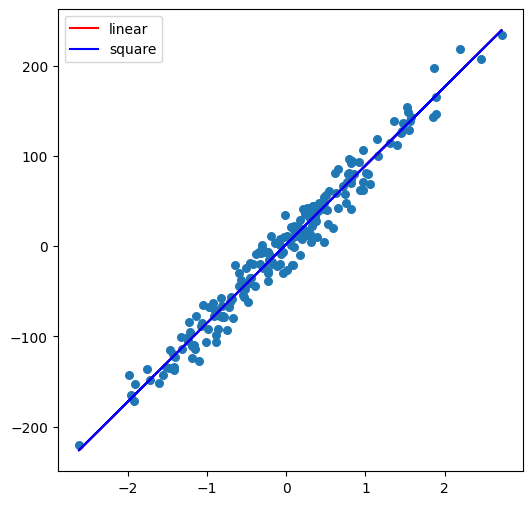

In [4]:
_, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X, y, s=30)
ax.plot(X, model1.predict(X), '-r', label='linear')
ax.plot(X, model1.predict(X), '-b', label='square')
ax.legend()
plt.show()

## Завдання 2
Порівняйте моделі з різним ступенем полінома і проаналізуйте перенавчання:

- Використовуйте синтетичні дані (make_regression, n_samples=200, n_features=1, noise=20).
- Побудуйте моделі для ступенів полінома: 2, 5, 10.
- Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
- Для кожної моделі обчисліть R² на навчальній і тестовій вибірках.
- Оформіть результати в таблиці:
|Ступінь полінома|R² навч.|R² тест.|
|-|-|-|
|2...|...|
|5...|...|
|10...|...|

In [5]:
# Використовуйте синтетичні дані (make_regression, n_samples=200, n_features=1, noise=20).
X2, y2 = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)
# Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [6]:
degrees = [2, 5, 10]
models = [
    make_pipeline(
        PolynomialFeatures(degree=d),
        LinearRegression()
    )
    for d in degrees
]
for m in models:
    m.fit(xtrain, ytrain)

In [7]:
# Для кожної моделі обчисліть R² на навчальній і тестовій вибірках.
from IPython.display import Markdown as md
import sklearn.metrics as sm

r2_train = [sm.r2_score(ytrain, m.predict(xtrain)) for m in models]
r2_test  = [sm.r2_score(ytest,  m.predict(xtest))  for m in models]

md("\n".join((
    "|Ступінь полінома|R² навч.|R² тест.|",
    "|-|-|-|",
    *(f"{degrees[i]}|{r2_train[i]}|{r2_test[i]}|" for i in range(len(degrees)))
)))

|Ступінь полінома|R² навч.|R² тест.|
|-|-|-|
2|0.9399759367954303|0.9449541323633316|
5|0.9415912035254085|0.886133123794706|
10|0.9428972243032762|-31.840955119114362|

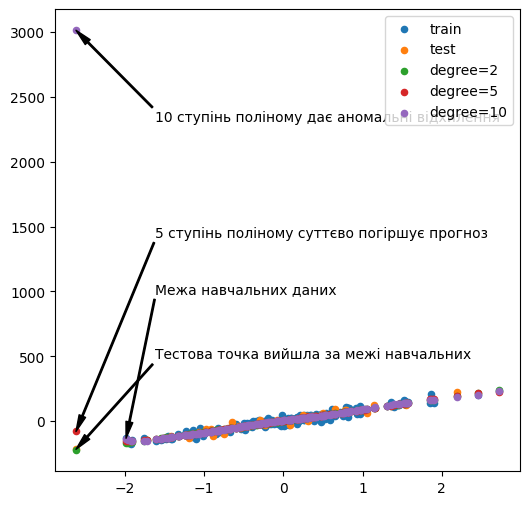

In [8]:
# візуалізуємо результати

predictions = [m.predict(X) for m in models]

_, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xtrain, ytrain, s=20, label='train')
ax.scatter(xtest, ytest, s=20, label='test')
for i in range(len(degrees)):
    ax.scatter(X2, predictions[i], s=20, label=f'degree={degrees[i]}')
#for i in range(len(xtrain)):
#   ax.annotate(f"{i}", (xtrain[i][0], ytrain[i]))
ax.annotate(
    "Межа навчальних даних", 
    (xtrain[65][0], ytrain[65]), 
    (xtest[15][0] + 1, ytest[15] + 1200),
    arrowprops={"fc": "black", "width": 1, "headwidth": 5}
)
ax.annotate(
    "Тестова точка вийшла за межі навчальних", 
    (xtest[15][0], ytest[15]), 
    (xtest[15][0] + 1, ytest[15] + 700),
    arrowprops={"fc": "black", "width": 1, "headwidth": 5}
)

ax.annotate(
    "5 ступінь поліному суттєво погіршує прогноз", 
    (xtest[15][0], predictions[1][177]), 
    (xtest[15][0] + 1, predictions[1][177] + 1500),
    arrowprops={"fc": "black", "width": 1, "headwidth": 5}
)

ax.annotate(
    "10 ступінь поліному дає аномальні відхилення", 
    (xtest[15][0], predictions[2][177]), 
    (xtest[15][0] + 1, predictions[2][177] - 700),
    arrowprops={"fc": "black", "width": 1, "headwidth": 5}
)
 
 
ax.legend()
plt.show()

Негативні наслідки поліноміальної регресії - "хвости" - поведінка поза межами навчальної послідовності.
Чим вище ступінь поліному, тим швидше він зростає (або спадає у мінус) з віддаленням від "центру"

## Завдання 3
Застосуйте Lasso і порівняйте результат зі звичайною лінійною регресією:

- Згенеруйте дані за допомогою make_regression (n_samples=500, n_features=20, n_informative=5, noise=10, random_state=42).
- Навчіть модель LinearRegression і модель Lasso(alpha=0.1).
- Розділіть дані на train/test(80/20, random_state=42).
- Порівняйте R² на тестовій вибірці.
- Виведіть кількість коефіцієнтів, які Lasso занулила.

In [9]:
X3, y3 =  make_regression(n_samples=500, n_features=20, n_informative=5, noise=10, random_state=42)
# Ілюстрація роботи з параметрами (features), від яких немає залежності

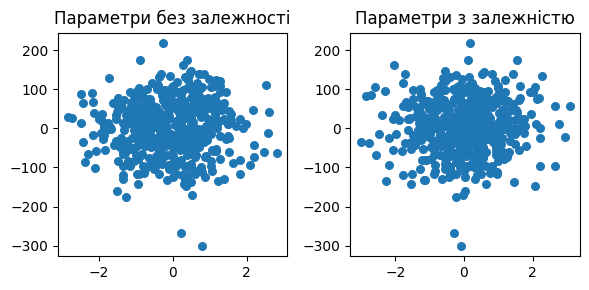

In [10]:
_, (ax1, ax2) = plt.subplots(1,2, figsize=(6, 3))
ax1.scatter(X3[:,0], y3, s=30)
ax1.set_title("Параметри без залежності")
ax2.scatter(X3[:,3], y3, s=30)
ax2.set_title("Параметри з залежністю")
plt.tight_layout()
plt.show()

In [11]:
# Розділіть дані на train/test(80/20, random_state=42).
x3train, x3test, y3train, y3test =  train_test_split(X3, y3, test_size=0.2, random_state=42)

In [12]:
# Навчіть модель LinearRegression
model3_linear = LinearRegression()
model3_linear.fit(x3train, y3train)
model3_linear.coef_

array([-4.77635006e-02,  4.54273134e-01,  7.34035282e+00, -5.56868091e-01,
       -4.37600534e-01,  3.69274396e-01,  5.87302519e+01,  3.13384503e+01,
        2.17954291e-01,  1.06012093e+01, -7.84637453e-01,  1.84518416e-02,
        8.11156893e-01,  9.39727814e+00, -7.06551427e-02, -7.10095431e-03,
        9.65836028e-02,  2.34853651e-02,  6.88232899e-01, -8.96721545e-02])

Lasso (Least Absolute Shrinkage and Selection Operator) Regression is a linear modeling technique that prevents overfitting by adding an L1 penalty to the model's loss function. It penalizes the absolute magnitude of coefficients, which naturally shrinks some coefficients to exactly zero, performing automatic feature selection

In [13]:
# Навчіть модель Lasso(alpha=0.1)       # alpha=0 - звичайна лінійна регресія
from sklearn.linear_model import Lasso  # alpha=0.1 - занулено 5 коеф.
model3_lasso = Lasso(alpha=1)           # alpha=0.2 - занулено 7 коеф.
model3_lasso.fit(x3train, y3train)      # alpha=0.5 - занулено 10 коеф.
model3_lasso.coef_                      # alpha=1 - занулено 15 коеф.

array([-0.        ,  0.        ,  6.27444181, -0.        , -0.        ,
        0.        , 57.77523145, 30.33667882,  0.        ,  9.70728915,
       -0.        ,  0.        ,  0.        ,  8.33496848, -0.        ,
       -0.        ,  0.        , -0.        ,  0.        , -0.        ])

In [14]:
zero_count = []
for i in model3_lasso.coef_:
    if i == 0:
        zero_count.append(i)
len(zero_count)

15

In [15]:
# Порівняйте R² на тестовій вибірці
md("\n".join((
    "|Модель|R² тест.|",
    "|-|-|",
    f"|LinearRegression|{sm.r2_score(y3test, model3_linear.predict(x3test))}|",
    f"|Lasso|{sm.r2_score(y3test, model3_lasso.predict(x3test))}|",
    
)))

|Модель|R² тест.|
|-|-|
|LinearRegression|0.9784107098360567|
|Lasso|0.9790813568651102|

Модель Lasso дає кращі результати, ніж LinearRegression, за умови наявності великого шуму в даних.
У той же час, для ідеальних даних Lasso дає гірші результати. Висновок ти сильніший, чим більше параметр alpha

## Завдання 4
Перевірте вплив Ridge-регуляризації на якість моделі:

- Використовуйте ті самі дані, що й у Завданні 3.
- Навчіть модель LinearRegression і модель Ridge(alpha=1.0).
- Розділіть дані на train/test (80/20, random_state=42).
- Порівняйте R² на тестовій вибірці.
- Виведіть таблицю порівняння:

|Модель|Тест R²|Кількість ненульових коеф.
|-|-|-|
LinearRegression|...|...
Хребет(альфа=1.0)|...|...

*Ridge regression is a technique used to analyze multiple regression data that suffers from multicollinearity (highly correlated predictors). By adding a penalty to the model's coefficients, it reduces overfitting and improves generalization. It is also known as L2 regularization*

In [16]:
from sklearn.linear_model import Ridge

In [17]:
X4, y4 = make_regression(n_samples=500, n_features=20, n_informative=5, noise=0, random_state=42)
x4train, x4test, y4train, y4test =  train_test_split(X4, y4, test_size=0.2, random_state=42)

In [18]:
model4_linear = LinearRegression()
model4_linear.fit(x4train, y4train)
model4_linear.coef_


array([ 3.21255173e+01,  4.81836793e-14,  4.60345156e-15,  1.55300528e-14,
        1.24061755e-14,  1.03019194e+01, -3.17414252e-14, -6.20938188e-14,
       -1.49393943e-14, -6.66906980e-14,  3.05052885e-14, -1.69652132e-14,
        4.89487708e-14,  4.55397858e-14,  5.06260875e-14,  5.82869361e+01,
        2.61958147e-15,  8.54871729e-15,  9.42759779e+00,  7.18075454e+00])

In [19]:
eps = 1e-13
print(f"Вважаємо за нуль {sum(abs(model4_linear.coef_) < eps)} коефіцієнтів.")

Вважаємо за нуль 15 коефіцієнтів.


In [20]:
model4_ridge = Ridge(alpha=1.0)
model4_ridge.fit(x4train, y4train)
model4_ridge.coef_

array([ 3.20433310e+01,  7.65583693e-03,  1.17133000e-03,  3.83946685e-03,
        2.20273508e-03,  1.02617469e+01, -2.87541907e-04, -1.00988185e-03,
       -1.29186886e-02,  1.08427627e-02, -1.15133778e-02, -8.76198995e-03,
        1.88569995e-03,  1.04327131e-02,  7.25146785e-03,  5.81329157e+01,
        1.39558977e-02,  1.32741417e-02,  9.40019912e+00,  7.15783599e+00])

In [21]:
print(f"Вважаємо за нуль {sum(abs(model4_ridge.coef_) < eps)} коефіцієнтів.")

Вважаємо за нуль 0 коефіцієнтів.


In [22]:
md("\n".join((
    "|Модель|R² тест.|",
    "|-|-|",
    f"|LinearRegression|{sm.r2_score(y4test, model4_linear.predict(x4test))}|",
    f"|Lasso|{sm.r2_score(y4test, model4_ridge.predict(x4test))}|",
    f"|Lasso|{sum(abs(model4_ridge.coef_) < eps)}|",
)))

|Модель|R² тест.|
|-|-|
|LinearRegression|1.0|
|Lasso|0.9999913870386135|
|Lasso|0|

In [23]:
md("\n".join((
    "|Модель|R² тест.|Кількість ненульових коеф.",
    "|-|-|-|",
    f"|LinearRegression|{sm.r2_score(y4test, model4_linear.predict(x4test))}|{sum(abs(model4_linear.coef_) < eps)}|",
    f"|Ridge|{sm.r2_score(y4test, model4_ridge.predict(x4test))}|{sum(abs(model4_ridge.coef_) < eps)}|",
    
)))

|Модель|R² тест.|Кількість ненульових коеф.
|-|-|-|
|LinearRegression|1.0|15|
|Ridge|0.9999913870386135|0|